# 01.5 — ADME Biogen Public: Reference Paper Recreation

**Goal**: Reproduce the published results from the reference paper as faithfully as possible.

**Paper**: Fang et al. — *Prospective Validation of Machine Learning Algorithms for Absorption, Distribution, Metabolism, and Excretion Prediction: An Industrial Perspective*  
DOI: [10.1021/acs.jcim.3c00160](https://pubs.acs.org/doi/10.1021/acs.jcim.3c00160)

**Dataset**: Biogen public ADME dataset (3521 compounds, 6 endpoints: HLM, RLM, MDR1, SOL, PPB_H, PPB_R)

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 0 — Setup | Imports, paths, constants |
| 1 — Paper Methodology | Document exactly what the paper did |
| 2 — Data Loading & Preprocessing | Match paper's preprocessing |
| 3 — Featurization | Match paper's featurization |
| 4 — Models & Splits | Reproduce paper's models/splits |
| 5 — Results Comparison | Our numbers vs paper's numbers |

## 0 — Setup

> **NOTE**: The paper's train/test split files are needed to exactly reproduce their results.  
> **TODO (Zarif)**: Add the split files to `data/raw/` and update the `SPLIT_FILE` path below once available.

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_STATE = 42

DATA_RAW   = Path('../data/raw')
DATA_PROC  = Path('../data/processed')
FIGURES    = Path('../figures')

ADME_FILE  = DATA_RAW / 'ADME_public_set_3521.csv'
SPLIT_FILE_1 = DATA_RAW / 'TODO_split_file.csv'  # TODO: update once split files are provided

SDF_DIR = DATA_RAW.parent / 'sdfs'
LOG_FILE = DATA_PROC / 'sdf_standardization.log'

SDF_FILES = {
    'HLM':   SDF_DIR / 'ADME_HLM.sdf',
    'MDR1':  SDF_DIR / 'ADME_MDR1_ER.sdf',
    'RLM':   SDF_DIR / 'ADME_RLM.sdf',
    'SOL':   SDF_DIR / 'ADME_Sol.sdf',
    'PPB_H': SDF_DIR / 'ADME_hPPB.sdf',
    'PPB_R': SDF_DIR / 'ADME_rPPB.sdf',
}

print('Setup complete')
print(f'ADME file exists: {ADME_FILE.exists()}')
print(f'Split files exist: {SPLIT_FILE_1.exists()}  <-- update path once available')

In [ ]:
from src.eda import missing_value_report
from src.features import morgan_fingerprints, rdmoldes, rdkit_2d_features
from src.preprocessing import standardize

from rdkit import Chem
from rdkit.Chem import SDMolSupplier
from rdkit import Chem, DataStructs
from rdkit.Chem import rdMolDescriptors

from scipy.stats import gaussian_kde

import plotly.graph_objects as go

import contextlib

## 1 — Paper Methodology

Document exactly what the paper did before implementing anything. All details below are taken directly from Fang et al. (2023). Cross-reference with the paper when populating.

### 1.1 Endpoints reported

HLM - Human Liver Microsomal stability, reported as intrinsic clearance (CLint, mL/min/kg) 

MDR1-MDCK ER (Efflux Ratio)

Solubility at pH 6.8 (ug/mL)

RLM - Rat Liver Microsomal stability, reported as intrinsic clearance (CLint, mL/min/kg) 

hPPB - human plasma protein binding, percent unbound

rPPB - rat plasma protein binding, percent unbound

### 1.2 Featurization

For featurization, they used a few methods:

1. RDkit 2d descriptors (the paper said they used 316 on v2018.09.3.0, my version has 210 in Descriptors.descList, with descriptastorus selecting 200 of those, dropping 10 unstable/redundant ones), measurable and estimated physiochemical properties, continous.

Reviewing their soure code: https://github.com/molecularinformatics/Computational-ADME/blob/main/ML/ADME_ML_public.py they used, they called their descriptor set "rdMolDes", I copied their MDlist and put it in /src/RDKit_descriptors/MDlist.py as they seem to have handpicked a specific set of descriptors.

Note: They normalize these descriptors for SVM and Lasso, FCNN

2. FPFC4 note NOT ECFP4. 2d structural fingerprints, binary, vector, 1024 bits, r=4 (according to the paper, BUT line 187 in ADME_ML_public.py reveals they used radius = 2, so may have to test both to recreate their results, will follow the code rather than the paper), useFeatures=True

For SVM and Lasso, their code in ADME_ML_public.py shows they used Robubst scaler, fit and transform (separate steps for some reason on X_train instead of doing it in one go with fit_transform).

Note:

MPNN1 (without RDkit descriptors)
MPNN2 (with RDkit descriptors) uses rdkit_2d_normalized, see line 34 in MPNN_public.py along with "--no_features_scaling"

3.  RDkit 2d descriptrs + FPFC4 concatenated

4. rdkit_2d_normalized Note: Not the same as rdMolDes normalized

### 1.3 Split strategy

[TO FILL IN — how did they split? random? scaffold? temporal? what ratio? how many repeats/seeds?]  
> Note: Split files to be provided by Zarif (see Setup TODO above).

The paper used temporal splits for their in house ADME dataset, for their public dataset which is a combination of:

Enamine, eMolecules, WuXi LabNetwork, Mcule datasets, covering 3521 compounds, I believe they used grid search, with cross validation with a fold of k = 5 (RepeatedKFold). The public dataset does not have a time index so temporal splits are not possible with it, scaffold splits are possible but so far, I cant see any evidence that they used scaffold splits to the best of my knowledge dated: 22nd July 2026.


### 1.4 Models used and hyperparameters

RF, XGBoost, LightGBM, SVM, FCNN, MPNN models used

All models (except for MPNN) used either RDkit or FPFC4 OR both concatenated

MPNN learnt its own representations on its own OR combined it with RDkit

For hyperparameters, see src/hyperparameters/hyperparameters.py, all models except MPNN and FCNN populated

### 1.5 Metrics reported


The paper used the following to evaluate the performance of diff ML models:

1. Pearson r - to evaluate performance on the data set
2. MAE - to evaluate model predictivity on each individual component as a function of its distance from models domain of applicability

To compare models they used:

1) paired, one way ANOVA
2) post hoc pairwise Tukey test, performaned on pearson r on 20 in house datasets for each ADME endpoints.

Standard p<0.05 used


### 1.6 Paper's reported numbers (ground truth to reproduce)

Figures to regenerate, in order of what is easiest to recreate

#### 1.6.1 Table 2. Summary Statistics for Public ADME Data Set

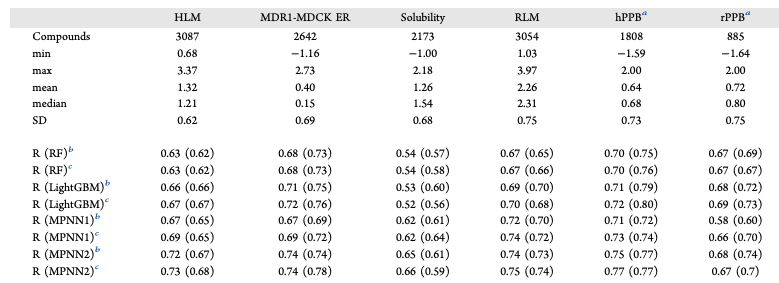

Summary statistics is the top half easy to recreate see section 2.1

#### 1.6.2 Fig 9: Density plot for the distribution of pairwise similarities between the public and Biogen ADME data sets.

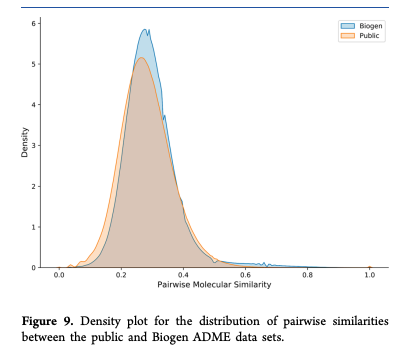

Density distribution of pairwise similarities for all pairs of
compounds in the public and Biogen ADME data sets
calculated using FCFP4 fingerprints.

Can recreate this fairly quickly, but just wont have their in house biogen dataset, will have only the public distribution.

Public should be around 0.28+- 0.08

Recreated in section 2.2

## 2 — Data Loading, EDA & Preprocessing

### 2.0 Loading the ADME data, creating endpoints

In [ ]:
# Load the raw ADME dataset

df = pd.read_csv(DATA_RAW / 'ADME_public_set_3521.csv')
print(df.shape)
df.head()

In [ ]:
ENDPOINTS = {
    'HLM':   'LOG HLM_CLint (mL/min/kg)',
    'MDR1':  'LOG MDR1-MDCK ER (B-A/A-B)',
    'SOL':   'LOG SOLUBILITY PH 6.8 (ug/mL)',
    'RLM':   'LOG RLM_CLint (mL/min/kg)',
    'PPB_H': 'LOG PLASMA PROTEIN BINDING (HUMAN) (% unbound)',
    'PPB_R': 'LOG PLASMA PROTEIN BINDING (RAT) (% unbound)',
}

### 2.1 Summary statistics to match table 2 from paper

In [ ]:
ENDPOINT_COLS = list(ENDPOINTS.values())

stats = df[ENDPOINT_COLS].agg(['count', 'min', 'max', 'mean', 'median', 'std'])
stats.columns = list(ENDPOINTS.keys())
stats.index = ['N', 'Min', 'Max', 'Mean', 'Median', 'Std']
stats.round(2)

Summary statistics matches table 2 summary statistics for public ADME dataset, however:

As they used CHEMBL data to augment as their inhouse data was limited

1. PPB_H = 194 here but in paper = 1808 (+1614 compounds)
2. PPB_R = 168 here but in paper = 885 (+717 compounds)

ChEMBL assay IDs: CHEMBL3301365, CHEMBL3301366

### 2.2 Density plot for distribution of pariwse similarities (Sorensen-Dice) to match Figure 9 from paper

In [ ]:
# Compute FCFP4 fingerprints (radius=2, nBits=1024, useFeatures=True — matches paper code)

fps = []
for smi in df['SMILES']:
    mol = Chem.MolFromSmiles(str(smi))
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024, useFeatures=True)
    fps.append(fp)

# Compute all pairwise Sørensen-Dice similarities (upper triangle only — ~6.2M pairs)
# Paper methods: "structural similarity measured using the Sorensen-Dice coefficient

sims = []
for i in range(len(fps)):
    sims.extend(DataStructs.BulkDiceSimilarity(fps[i], fps[i+1:]))

sims = np.array(sims)
print(f'Pairs: {len(sims):,}  |  Mean: {sims.mean():.3f}  |  Std: {sims.std():.3f}')
print(f'Paper (public): 0.28 ± 0.08')

In [ ]:
# Reuse sims from the cell above
kde = gaussian_kde(sims, bw_method=0.05)
x = np.linspace(0, 1, 500)

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=sims,
    histnorm='probability density',
    nbinsx=150,
    marker_color='steelblue',
    opacity=0.35,
    showlegend=False,
))

fig.add_trace(go.Scatter(
    x=x, y=kde(x),
    mode='lines',
    line=dict(color='steelblue', width=2),
    name=f'Public (mean={sims.mean():.2f} ± {sims.std():.2f})',
))

fig.add_vline(
    x=sims.mean(),
    line=dict(color='crimson', dash='dash', width=1.5),
)

fig.update_layout(
    title='Pairwise Similarity Distribution — Public ADME Dataset (FCFP4, Dice)',
    xaxis_title='Sørensen-Dice Similarity',
    yaxis_title='Density',
    template='plotly_white',
    legend=dict(x=0.65, y=0.95),
    width=750, height=450,
)

fig.show()

In [ ]:
# Recreates Fig S10 (SI) -- distribution of endpoint property values, Biogen vs public.
# We only have the public set here (no Biogen in-house data), so only that curve is shown --
# same limitation as Fig 9 above. Values are already log10-transformed in the source columns.

from plotly.subplots import make_subplots

AXIS_LABELS = {'HLM': 'log10(HLM)', 'MDR1': 'log10(MDR1-MDCK ER)'}
XLIMS = {'HLM': (0, 4), 'MDR1': (-2, 3.5)}

fig = make_subplots(rows=1, cols=2, subplot_titles=['HLM', 'MDR1'])

for i, ep in enumerate(['HLM', 'MDR1'], start=1):
    col = ENDPOINTS[ep]
    values = df[col].dropna().values
    kde = gaussian_kde(values)
    x = np.linspace(*XLIMS[ep], 300)

    fig.add_trace(
        go.Histogram(x=values, histnorm='probability density', nbinsx=40,
                     marker_color='steelblue', opacity=0.35, showlegend=(i == 1), name='Public'),
        row=1, col=i,
    )
    fig.add_trace(
        go.Scatter(x=x, y=kde(x), mode='lines', line=dict(color='steelblue', width=2), showlegend=False),
        row=1, col=i,
    )

    fig.update_xaxes(title_text=AXIS_LABELS[ep], range=list(XLIMS[ep]), row=1, col=i)
    fig.update_yaxes(title_text='Density', range=[0, 1], row=1, col=i)

fig.update_layout(
    title='Distribution of property values, per endpoint (public set only)',
    template='plotly_white', width=1000, height=450,
)
fig.show()


Matches with Figure S10 from the papers supplementary figures

##### Matplot lib plot (not a fan)

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sims, bins=150, density=True, alpha=0.35, color='steelblue')
kde = gaussian_kde(sims, bw_method=0.05)

x = np.linspace(0, 1, 500)
ax.plot(x, kde(x), color='steelblue', linewidth=2)
ax.axvline(sims.mean(), color='crimson', linestyle='--', linewidth=1.5,
           label=f'Mean = {sims.mean():.2f} ± {sims.std():.2f}')
ax.set_xlabel('Sørensen-Dice Similarity (FCFP4, 1024 bits)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Pairwise Similarity Distribution — Public ADME Dataset', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES / 'fig9_pairwise_similarity_public.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Preprocessing checks

In the methods section they reference 1-4 preprocessing filters applied, just checking here that the public dataset has them pre-applied. 

For Criterion 1) stereoisomer checks, I previously checked already in another notebook, so skipping that for now. 


Criterion 3 (MDR1 recovery >30%): raw recovery data not in public CSV — cannot verify, assumed pre-applied.

Criterion 4 (PPB plasma stability <50%): raw stability data not in public CSV — cannot verify, assumed pre-applied.

In [ ]:
SOL_COL = ENDPOINTS['SOL']
HLM_COL = ENDPOINTS['HLM']
RLM_COL = ENDPOINTS['RLM']

# Criterion 1 — Stereoisomers: confirmed 0 pairs in notebook 01, skipped here

# Criterion 2 — Solubility < 1.0 ug/mL → exclude from HLM and RLM
# log(1.0 ug/mL) = 0; compounds with LOG SOL < 0 are below threshold
low_sol = df[SOL_COL] < 0  # True where solubility is below threshold

n_low_sol        = low_sol.sum()
n_also_hlm       = (low_sol & df[HLM_COL].notna()).sum()
n_also_rlm       = (low_sol & df[RLM_COL].notna()).sum()
n_sol_missing    = df[SOL_COL].isna().sum()

print(f"Compounds with LOG SOL < 0 (< 1.0 ug/mL): {n_low_sol}")
print(f"  of which also have HLM values:           {n_also_hlm}  (would be removed from HLM)")
print(f"  of which also have RLM values:           {n_also_rlm}  (would be removed from RLM)")
print(f"Compounds with SOL missing (no measurement): {n_sol_missing}")
print()

In [ ]:
miss_report = missing_value_report(df, ENDPOINT_COLS)
print('Missing values per endpoint:')
display(miss_report)

# Recall 3521 compounds, so 434 missing just means those werent sent to the assay to be tested

In [ ]:
df.info()

Recall that hPPB and rPPB have a large % missing as I havent as of yet augmented with the same CHEMBL datasets they did.

Can add later, but for now focusing on HLM, RLM, MDR, SOL

### 2.4 — Loading SDF files & recovering augmented PPB data

**SMILES vs mol object vs conformer**
- SMILES is a text string encoding molecular connectivity only (no coordinates)
- A mol object is RDKit's in-memory representation of a molecule — it holds the graph structure
- A conformer is a set of (x, y, z) coordinates for every atom attached to a mol object

The paper loaded molecules from SDF files, not the CSV. An SDF file stores mol objects with
coordinates already embedded. Even "2D" SDFs (z=0 for all atoms) count as conformers in RDKit,
which is required for the geometry-dependent descriptors in rdMolDes (CalcPMI1/2/3, etc.).

Additionally, the SDFs for hPPB and rPPB include ChEMBL-augmented data not present in the
public CSV — recovering 1614 hPPB and 717 rPPB compounds.

In [ ]:
# HLM/MDR1/RLM/SOL have 'Vendor ID'; PPB_H/PPB_R (ChEMBL-augmented) use 'Internal ID'.
# These are different ID systems — joining on mol_id would create separate rows.
# Use canonical SMILES as the common key instead.
#
# Property value is read BEFORE standardize() to avoid any ambiguity about
# whether SDF properties survive the standardization steps.
# All RDKit info/warning output during standardization is redirected to LOG_FILE
# rather than suppressed — review it after loading to catch any genuine issues.

ep_dfs = {}
with open(LOG_FILE, 'w') as log_fh, contextlib.redirect_stderr(log_fh):
    for ep, path in SDF_FILES.items():
        col = ENDPOINTS[ep]
        rows = []
        for mol in SDMolSupplier(str(path)):
            if mol is None:
                continue
            value = float(mol.GetProp(col))   # read before standardization
            mol = standardize(mol)
            rows.append({
                'can_smi': Chem.MolToSmiles(mol),
                'mol':     mol,
                col:       value,
            })
        ep_dfs[ep] = pd.DataFrame(rows).drop_duplicates('can_smi')
        print(f"{ep}: {len(ep_dfs[ep])} molecules loaded")

# Union of all unique molecules, then left-merge each endpoint
all_mols = (
    pd.concat([d[['can_smi', 'mol']] for d in ep_dfs.values()])
    .drop_duplicates('can_smi')
    .reset_index(drop=True)
)
df_sdf = all_mols.copy()
for ep, col in ENDPOINTS.items():
    df_sdf = df_sdf.merge(ep_dfs[ep][['can_smi', col]], on='can_smi', how='left')

print(f"\nCombined df_sdf: {df_sdf.shape}")
print(f"RDKit logs written to: {LOG_FILE}")

In [ ]:
csv_counts = df[list(ENDPOINTS.values())].count()
sdf_counts = df_sdf[list(ENDPOINTS.values())].count()
pd.DataFrame({
    'CSV N': csv_counts,
    'SDF N': sdf_counts,
    'Δ': sdf_counts - csv_counts
}).rename(index=dict(zip(ENDPOINTS.values(), ENDPOINTS.keys())))

hlm, mdr1, sol, rlm lost 1 chemical compound each, with hppb losing 13 and hppb losing 9 due to standardization, if you skip that, they match exactly with Table 2 summary statistics and public adme dataset from paper, this is expected and the authors would have encountered the same thing due to the standarization process!

## 3 — Featurization

In [ ]:
# Per-endpoint feature matrices: filter to non-NaN rows, then featurize
# X_fcfp4     → FCFP4 Morgan fingerprints (1024 bits)
# X_rdkit     → rdmoldes (316 features, uses SDF conformers for 3D descriptors)
# X_hybrid    → concatenation of both (1340 features) — FCFP4 first, then rdMolDes (matches paper order)
# X_rdkit_norm → rdkit_2d_normalized via descriptastorus (200 features) — for MPNN (Section 4)

feat = {}  # feat[ep] = {'y': array, 'fcfp4': array, 'rdkit': array, 'hybrid': array, 'rdkit_norm': array}

for ep, col in ENDPOINTS.items():
    sub = df_sdf[df_sdf[col].notna()].reset_index(drop=True)
    mols   = sub['mol'].tolist()
    smiles = sub['can_smi'].tolist()
    y      = sub[col].values

    X_fcfp4     = morgan_fingerprints(smiles)
    X_rdkit     = rdmoldes(mols)
    X_hybrid    = np.hstack([X_fcfp4, X_rdkit])
    X_rdkit_norm = rdkit_2d_features(smiles)

    feat[ep] = {
        'y':         y,
        'fcfp4':     X_fcfp4,
        'rdkit':     X_rdkit,
        'hybrid':    X_hybrid,
        'rdkit_norm': X_rdkit_norm,
    }
    print(f"{ep:6s}  N={len(y):4d}  fcfp4={X_fcfp4.shape[1]}  rdkit={X_rdkit.shape[1]}  "
          f"hybrid={X_hybrid.shape[1]}  rdkit_norm={X_rdkit_norm.shape[1]}")

NOTE - add : 'smiles':    smiles, to the dict feat so have access to smile string later, when done so, modify 5.4 so dont have to reload the smile string

Once patched and re-run, Section 5.4 can drop the shuffle-replay reconstruction entirely and just do smiles_train, smiles_test = train_test_split(feat[ep]['smiles'], test_size=0.2, random_state=84) — paired with the same shuffle. You'd still want the assert np.allclose(...) sanity check the first time you swap it in, just to confirm nothing else downstream depends on the old recovery path.

**Note — hybrid construction: our approach vs the paper**

The paper (ADME_ML_public.py "Merge descriptors" section) builds the hybrid row-by-row per molecule:
appends 1024 FCFP4 bit values (as strings "0"/"1") then 316 rdMolDes values (as strings) into a list,
writes to CSV, reads back — the CSV round-trip converts everything to floats.

We do the same thing in two lines:
```
X_fcfp4  (N, 1024) — int array, FCFP4 bits occupy columns 0–1023
X_rdkit  (N, 316)  — float64 array, rdMolDes occupy columns 1024–1339
np.hstack([X_fcfp4, X_rdkit]) → (N, 1340) float64
```
`hstack` places the two arrays side by side, row by row. numpy upcasts int → float64 during the join,
which is exactly what the paper's CSV round-trip produces. Same column order, same values, same dtype
going into the model — just two different mechanical paths to the same (N, 1340) feature matrix.

**Note — rdkit_norm (X_rdkit_norm)**

`rdkit_2d_normalized` is a descriptastorus feature set — NOT a normalized version of rdMolDes.
They are different descriptor sets:
- `rdMolDes` (316): paper's hand-picked descriptors, used for RF / XGBoost / LightGBM / SVM / Lasso
- `rdkit_2d_normalized` (200): descriptastorus selection, normalized — used for MPNN only, this is what they used in the reference paper and codebase for the mpnn model when it uses its own learned representations + the rdkit features

ChemProp calls descriptastorus internally via `--features_generator rdkit_2d_normalized`.
Our `rdkit_2d_features()` calls descriptastorus directly — same 200 features, no ChemProp middleman.
Computed here now so it is ready when MPNN is implemented in Section 4.

## 4 — Models & Splits

### 4.0 Recreating paper's exact procedure

Read `ADME_ML_public.py` (github.com/molecularinformatics/Computational-ADME) to
resolve exactly how splitting/CV/tuning fit together:

1. `shuffle(X_data, Y_data, random_state=42)` on the full endpoint dataset.
2. One 80/20 `train_test_split(..., test_size=0.2, random_state=84)` — a single random split,
   not stratified, not scaffold/temporal (latter is done but not shared).
3. **Optionally** tune hyperparameters — a single pass of sequential, staged `GridSearchCV` on
   `X_train` only, `cv=5` (plain KFold), `scoring='r2'`. RF/SVM/Lasso tune in one
   stage; XGBoost (5 stages) and LightGBM (4 stages) tune sequentially — fit stage 1, lock in
   `best_params_`, fit stage 2 with that locked in, etc. This is why `hyperparams.py` has
   `param_search1_XGB..5_XGB` / `param_search1_LGB..4_LGB` — they're the paper's staged
   tuning grids. The "combined" `param_search_XGB`/`param_search_LGB` dicts are
   never referenced anywhere in the paper's script — dead code left over from an earlier,
   simpler (all-at-once) approach, superseded by the staged strategy. We don't use them either;
   kept in `hyperparams.py` for reference only.
4. `model_validation(X_train, Y_train, X_test, Y_test, model)` — CV happens **within the
   already-fixed `X_train` partition from step 2**, not as a fresh split of its own:
   - `Pearson_r_CV` = mean of `cross_val_score(model, X_train, Y_train, scoring=pearson_scorer, cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=128))` — a purely diagnostic CV estimate on the training set. All 15 (5×3) refit models from this step are discarded once their scores are averaged.
   - Separately, `model.fit(X_train, Y_train)` fits fresh on the **entire** `X_train` — the actual production model. `Pearson_r_test` is Pearson r between `Y_test` and that model's predictions.
5. SVM, Lasso, FCNN require: Scaling - `RobustScaler().fit(X_train)` then splitting calls. RF/XGBoost/LightGBM/MPNN: no scaling.

The paper's script never computes MAE at all (no `mean_absolute_error` import/usage anywhere in
it) — whatever domain-of-applicability MAE analysis the paper text describes must live in a
separate, unpublished script. We add MAE ourselves below, from the same test-set predictions.

**Runtime note**: 4 endpoints × 3 featuresets × 5 models × 2 arms (base/tuned) = 120
`model_validation` calls, plus staged grid search for every "tuned" arm run (XGBoost/LightGBM's
staged searches are the expensive ones, especially on the 1340-dim hybrid featureset).
Running the "base" arm first for speed generally, and for sanity-checks before committing to the full "tuned" run.

### 4.1 Data setup — shuffle, split, scale (once per endpoint × featureset)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.utils import shuffle
from sklearn.base import clone
import joblib

from src.hyperparams import PARAM_GRID_STAGES, n_jobs_cv
from src.models import get_paper_models, tune_paper_model, model_validation
from src.metrics import mae

FEATURESETS = ['fcfp4', 'rdkit', 'hybrid']
MODEL_ENDPOINTS = [ep for ep in ENDPOINTS if ep not in ('PPB_H', 'PPB_R')]  # data quantity quite small for these two endpoints, so skip them for now.

splits = {}  # splits[(ep, fs)] = {'X_train','X_test','y_train','y_test','X_train_scaled','X_test_scaled'}

for ep in MODEL_ENDPOINTS:
    for fs in FEATURESETS:
        # shuffle() randomly permutes row order in unison across paired arrays, using a fixed
        # random_state for reproducibility. The paper shuffles the FULL dataset (their X_data,
        # Y_data) before splitting — not X_train/X_test separately after the fact — so we do
        # the same: shuffle first, then split. train_test_split also shuffles internally by
        # default (shuffle=True), so calling shuffle() first is redundant — odd, but it's what
        # the paper's code does, so we keep it for fidelity rather than "fix" it away.
        X, y = shuffle(feat[ep][fs], feat[ep]['y'], random_state=42)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=84)

        # RobustScaler: needed for SVM, Lasso now, and FCNN later (not trained this session).
        # Fit once per (ep, fs) here rather than per-model, so it's ready for FCNN without
        # redoing this step.
        scaler = RobustScaler().fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        splits[(ep, fs)] = {
            'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test,
            'X_train_scaled': X_train_scaled, 'X_test_scaled': X_test_scaled,
        }

joblib.dump(splits, DATA_PROC / 'section4_splits.pkl')
print(f'Prepared {len(splits)} (endpoint, featureset) splits')

### 4.2 Model training/evaluation loop — RF, SVM, XGBoost, LightGBM, Lasso

In [ ]:
# 'base' arm = paper's param_base_* defaults, model_validation only
# 'tuned' arm = staged GridSearchCV (PARAM_GRID_STAGES) first, then model_validation
# Reported metrics are Pearson_r_CV, Pearson_r_test, MAE -- matching what their notebook
# n_jobs=n_jobs_cv on model_validation parallelizes the 15 RepeatedKFold folds -- the paper's
# original script ran these serially, which is the main reason a base-arm run took ~30min.

rows = []
predictions = {}  # predictions[(ep, fs, model_name, arm)] = {'y_test':..., 'y_pred_test':..., 'cv_scores':...}

for (ep, fs), split in splits.items():
    for model_name, model in get_paper_models().items():
        if model_name in ('SVM', 'Lasso'):
            X_train, X_test = split['X_train_scaled'], split['X_test_scaled']
        else:
            X_train, X_test = split['X_train'], split['X_test']
        y_train, y_test = split['y_train'], split['y_test']

        for arm in ('base',): #, 'tuned'):
            m = clone(model)
            if arm == 'tuned':
                tune_paper_model(m, X_train, y_train, PARAM_GRID_STAGES[model_name], n_jobs_cv=n_jobs_cv)
            result = model_validation(m, X_train, y_train, X_test, y_test, n_jobs=n_jobs_cv)
            rows.append({
                'endpoint': ep, 'featureset': fs, 'model': model_name, 'arm': arm,
                'Pearson_r_CV': result['Pearson_r_CV'],
                'Pearson_r_test': result['Pearson_r_test'],
                'MAE': mae(y_test, result['y_pred_test']),
            })
            # cv_scores: the 15 individual RepeatedKFold fold scores model_validation computes
            # internally (only their mean, Pearson_r_CV, was kept before) -- persisted here so
            # Section 5's boxplots (5.3, 5.3b) have a real per-model/featureset distribution to
            # draw from, matching the paper's "Pearson r for N test sets" boxplot style.
            predictions[(ep, fs, model_name, arm)] = {
                'y_test': y_test, 'y_pred_test': result['y_pred_test'], 'cv_scores': result['cv_scores'],
            }

    print(f'{ep:6s} {fs:6s} done')

results_df = pd.DataFrame(rows)
results_df.to_csv(DATA_PROC / 'section4_paper_recreation_results.csv', index=False)
joblib.dump(predictions, DATA_PROC / 'section4_test_predictions.pkl')
print(results_df.shape)
results_df.head()


### 4.2a — Diagnostic: how widespread is the NaN Pearson_r_CV / Pearson_r_test issue?

In [ ]:
nan_rows = results_df[results_df['Pearson_r_CV'].isna() | results_df['Pearson_r_test'].isna()]
print(f"{len(nan_rows)}/{len(results_df)} rows have NaN Pearson_r_CV and/or Pearson_r_test\n")

print("By model:")
display(nan_rows.groupby('model').size())

print("\nBy (model, featureset):")
display(nan_rows.groupby(['model', 'featureset']).size())

print("\nAffected rows:")
display(nan_rows[['endpoint', 'featureset', 'model', 'arm', 'Pearson_r_CV', 'Pearson_r_test', 'MAE']])

For Lasso on the fcfp4 featureset, alpha=0.1 is strong enough to shrink all 1024 (binary) fingerprint-bit coefficients to zero, across every endpoint — leaving an intercept-only model that predicts the same constant value for every molecule, so Pearson r is undefined (NaN) rather than computable.

### 4.3 — Scaffold split (come back to this after section 5 is complete)

The paper used temporal splits on their in-house dataset; not reproducible here (public set has
no timestamp/assay-date column). We can test out scaffold splits (RDKit or datamol) after some
research into what's standard and potentially suitable for this dataset — left as a TODO for a
later session. The paper reports similar Tanimoto/Sørensen–Dice similarity profiles between
their in-house and public sets, and states they ran the same experiments on the public set with
comparable results — so results here should show the same trend even though it isn't an exact
reproduction of their temporal-split numbers.

The get_bemis_murcko_clusters method identifies the Bemis-Murcko frameworks, as defined by the RDKit, in each molecule and assigns each unique scaffold to a cluster.

df['scaffold_cluster'] = uru.get_bemis_murcko_clusters(df.SMILES)

## 5 — Results Comparison

Compare our reproduced numbers against the paper's reported numbers.

If restarted kernel, run 0-section 3, then the below code:

splits = joblib.load(DATA_PROC / 'section4_splits.pkl')

predictions = joblib.load(DATA_PROC / 'section4_test_predictions.pkl')

results_df = pd.read_csv(DATA_PROC / 'section4_paper_recreation_results.csv')'''

### 5.1 — MAE summary table

Paper's domain-of-applicability metric. All values below are from the `'base'` arm (paper's
default hyperparameters) — the `'tuned'` arm hasn't been run yet (see Section 5.6).

In [ ]:
base_df = results_df[results_df['arm'] == 'base'].copy()

# dropna=False: without it, pivot_table silently DROPS any column that's 100% NaN across every
# endpoint (Lasso+fcfp4 is all-NaN for Pearson_r_test, see 5.2)
mae_table = base_df.pivot_table(index='endpoint', columns=['model', 'featureset'], values='MAE', dropna=False)
mae_table = mae_table.reindex(index=['HLM', 'MDR1', 'SOL', 'RLM'])
# MAE itself is not NaN for Lasso+fcfp4 (Section 4.2a)
mae_table.round(3)


### 5.2 — Pearson r summary table

The paper's headline reported metric. Using `Pearson_r_test` (held-out test set, from the model
fit on the full training set)

In [ ]:
pearson_table = base_df.pivot_table(index='endpoint', columns=['model', 'featureset'], values='Pearson_r_test', dropna=False)
pearson_table = pearson_table.reindex(index=['HLM', 'MDR1', 'SOL', 'RLM'])
print("NaN = Lasso+fcfp4 collapse (Section 4.2a) -- expected, not missing data.")
pearson_table.round(3)

### 5.3 -- Pearson r boxplots per model, per endpoint (Papers Figure 1)

Matches the paper's model-comparison figure style (one box per model, spread from repeated
held-out evaluation). Box = that model's 15 RepeatedKFold
CV-fold Pearson r scores (persisted in Section 4.2 as `cv_scores`), using a single representative
featureset (`REPR_FEATURESET`, defaults to `'hybrid'`) per model.

Not an exact analog of the paper's figure -- their spread comes from 20 independent in-house
datasets; ours comes from CV-fold resampling of a single train/test split -- but it's the closest
real distribution available, and produces the same box-and-whisker shape.


In [ ]:
REPR_FEATURESET = 'hybrid'  # single representative featureset for this model-comparison boxplot
model_names = ['RF', 'SVM', 'XGBoost', 'LightGBM', 'Lasso']
endpoints_list = ['HLM', 'RLM', 'MDR1', 'SOL']

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=True)
axes = axes.flatten()

for ax, ep in zip(axes, endpoints_list):
    groups = []
    for m in model_names:
        pred = predictions.get((ep, REPR_FEATURESET, m, 'base'))
        scores = np.asarray(pred['cv_scores']) if pred is not None else np.array([])
        scores = scores[~np.isnan(scores)]
        groups.append(scores)
    ax.boxplot(groups, labels=model_names)
    ax.set_title(ep, fontsize=11)
    ax.set_ylabel('Pearson r (CV folds)')
    ax.set_ylim(0.4, 1.0)
    ax.grid(alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle(f'Pearson r per model, per endpoint (15 CV-fold scores, featureset={REPR_FEATURESET})', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'section5_pearson_r_boxplot_per_endpoint.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3b -- Effect of molecular representation on model performance (Papers Figure 5)

Compares FCFP4, RDKit, and hybrid representations for RF and LightGBM (FCNN not yet
available -- add once implemented) on HLM and MDR1. Box = the same 15 CV-fold Pearson r scores
per (model, featureset) used in Section 5.3.


In [ ]:
from matplotlib.patches import Patch

REPR_MODELS = ['RF', 'LightGBM']  # FCNN to be added once implemented
REPR_FEATURESETS = ['fcfp4', 'rdkit', 'hybrid']
REPR_ENDPOINTS = ['HLM', 'MDR1']
FS_COLORS = {'fcfp4': 'white', 'rdkit': 'black', 'hybrid': 'lightgrey'}

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, ep in zip(axes, REPR_ENDPOINTS):
    positions, groups, box_fs = [], [], []
    xticks, xticklabels = [], []
    pos = 0

    for m in REPR_MODELS:
        cluster_start = pos
        for fs in REPR_FEATURESETS:
            pred = predictions.get((ep, fs, m, 'base'))
            scores = np.asarray(pred['cv_scores']) if pred is not None else np.array([])
            scores = scores[~np.isnan(scores)]
            groups.append(scores)
            positions.append(pos)
            box_fs.append(fs)
            pos += 1
        xticks.append((cluster_start + pos - 1) / 2)
        xticklabels.append(m)
        pos += 1  # gap between model clusters

    bp = ax.boxplot(groups, positions=positions, widths=0.6, patch_artist=True)
    for patch, fs in zip(bp['boxes'], box_fs):
        patch.set_facecolor(FS_COLORS[fs])

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_title(ep, fontsize=11)
    ax.set_ylabel('Pearson r (CV folds)')
    ax.set_ylim(0.4, 1.0)
    ax.grid(alpha=0.3, axis='y')

legend_handles = [Patch(facecolor=FS_COLORS[fs], edgecolor='black', label=fs) for fs in REPR_FEATURESETS]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=8)

fig.suptitle('Effect of molecular representation on model performance (15 CV-fold Pearson r scores)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'section5_representation_effect_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 -- Similarity-binned MAE (RF & LightGBM, HLM & MDR1), (Papers Figure 6) - WIP

FCFP4 fingerprints at **radius=2** matching the code for the paper, Dice similarity, mean of the top-5 nearest
training-set neighbours per test compound, binned to the nearest 0.1.

Section 4's `feat[ep]` doesn't retain SMILES, so `smiles_train`/`smiles_test` are recovered here
by replaying the *exact same* `shuffle(random_state=42)` -> `train_test_split(random_state=84)`
calls Section 4 used on the SMILES list for each endpoint. `shuffle`'s permutation depends only
on array length and `random_state`, not values, so this reproduces the identical row order -- the
assertion below checks the recovered `y_test` against Section 4's stored `y_test` before trusting
`smiles_test`'s order.

Using the `'hybrid'` featureset as the representative one for the MODEL predictions being
plotted here (change `SIM_FEATURESET` below if you'd rather use `'fcfp4'` or `'rdkit'`) -- this
is separate from the similarity metric itself, which is always FCFP4 regardless.

**Why some bars are missing / lack error bars**: bins are only plotted if at least one test
compound actually falls into them -- that's a real property of the similarity distribution in
this test set, not a binning bug. Error bars need at least 2 samples in a bin to compute a
standard deviation -- a bin with exactly 1 compound has an undefined std, so no error bar is
drawn for it. Each bar is annotated with its sample count (`n=`) so this is visible directly in
the plot.


In [ ]:
from rdkit.Chem import AllChem
from rdkit import DataStructs

SIM_FEATURESET = 'hybrid'
TOP_K = 5

def _fcfp4_fps(smiles_list, n_bits=1024):
    """FCFP fingerprints (radius=2, 1024-bit, useFeatures=True) -- dedicated similarity
    fingerprint, matching this notebook's own Section 3 modelling featurization."""
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits, useFeatures=True))
    return fps

sim_df_records = []

for ep in ['HLM', 'RLM', 'MDR1', 'SOL']:
#for ep in ['HLM', 'MDR1']:
    col = ENDPOINTS[ep]
    sub = df_sdf[df_sdf[col].notna()].reset_index(drop=True)
    smiles_all = sub['can_smi'].tolist()
    y_all = sub[col].values

    smiles_shuf, y_shuf = shuffle(smiles_all, y_all, random_state=42)
    smiles_train, smiles_test, _, y_test_chk = train_test_split(
        smiles_shuf, y_shuf, test_size=0.2, random_state=84
    )

    stored_y_test = predictions[(ep, SIM_FEATURESET, 'RF', 'base')]['y_test']
    assert np.allclose(np.asarray(y_test_chk), np.asarray(stored_y_test)), \
        f"Smiles recovery misaligned for {ep} — check shuffle/split random_states match Section 4"

    train_fps = _fcfp4_fps(smiles_train)
    test_fps  = _fcfp4_fps(smiles_test)

    mean_top5_sims = np.array([
        np.mean(sorted(DataStructs.BulkDiceSimilarity(fp, train_fps), reverse=True)[:TOP_K])
        for fp in test_fps
    ])
    sim_bins = np.clip(np.floor(mean_top5_sims * 10) / 10, 0.0, 0.9)

    for model_name in ['RF', 'LightGBM']:
        pred = predictions[(ep, SIM_FEATURESET, model_name, 'base')]
        abs_errors = np.abs(np.asarray(pred['y_test']) - np.asarray(pred['y_pred_test']))
        for sim_bin, abs_err in zip(sim_bins, abs_errors):
            sim_df_records.append({'endpoint': ep, 'model': model_name, 'sim_bin': sim_bin, 'abs_error': abs_err})

sim_df = pd.DataFrame(sim_df_records)
print(f'Records: {len(sim_df)}')
sim_df.head()


In [ ]:
bar_colors = plt.cm.Greys(np.linspace(0.8, 0.3, 10))

for ep in ['HLM', 'RLM', 'MDR1', 'SOL']:
#for ep in ['HLM', 'MDR1']:
    ep_df = sim_df[sim_df['endpoint'] == ep]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

    for ax, model_name in zip(axes, ['RF', 'LightGBM']):
        m_df = ep_df[ep_df['model'] == model_name]
        stats = m_df.groupby('sim_bin')['abs_error'].agg(['mean', 'std', 'count'])

        for j, (sim_bin, row) in enumerate(stats.iterrows()):
            ax.bar(j, row['mean'], color=bar_colors[int(round(sim_bin * 10))], width=0.7, alpha=0.95)
            if row['count'] > 1:
                ax.errorbar(j, row['mean'], yerr=row['std'], fmt='none', color='black', capsize=3, linewidth=1)
            ax.text(j, row['mean'], f"n={int(row['count'])}", ha='center', va='bottom', fontsize=7)

        ax.set_title(model_name, fontsize=11)
        ax.set_xlabel('Mean top-5 Dice similarity to training set', fontsize=9)
        ax.set_ylabel('Mean absolute error', fontsize=9)
        ax.set_xticks(range(len(stats)))
        ax.set_xticklabels([f'({b:.1f},{b+0.1:.1f}]' for b in stats.index], rotation=45, ha='right', fontsize=8)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.3, axis='y')

    fig.suptitle(f'Similarity-Binned MAE -- {ep} (FCFP4 radius=2, Dice, mean top-5, 0.1 bins, featureset={SIM_FEATURESET})', fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES / f'section5_sim_binned_mae_{ep}.png', dpi=150, bbox_inches='tight')
    plt.show()


### 5.5 -- ANOVA + Tukey HSD post-hoc, per endpoint (items 2 & 3) - WIP

The paper ran paired one-way ANOVA + Tukey HSD on Pearson r across 20 in-house datasets **for
each ADME endpoint separately** -- not pooled across endpoints. Matching that structure here:
one ANOVA + Tukey HSD per endpoint, using the 3 featuresets as the paired "subjects" for that
endpoint (`AnovaRM`, repeated-measures ANOVA -- correctly models this paired design, unlike a
plain one-way ANOVA which assumes independent groups).

Caveat: this only gives 2-3 paired subjects per endpoint (fewer once `fcfp4` is dropped for
endpoints where Lasso is `NaN` there -- see Section 4.2a), which is a very small sample for a
repeated-measures ANOVA. Treat the per-endpoint F/p values as indicative, not conclusive --
`AnovaRM` may fail outright for an endpoint if too few balanced subjects remain, in which case
the heatmap still renders from the (unaffected) Tukey HSD test, just without an ANOVA
F/p annotation.

Heatmap colour is binned by significance level (NS / p<0.05 / p<0.01 / p<0.001) rather than a
continuous mean-difference scale -- easier to read at a glance than a diverging colour ramp.
Each cell is still annotated with the actual `meandiff` value plus its significance band.
`pairwise_tukeyhsd`'s summary table (`group1, group2, meandiff, p-adj, reject`) is both each
heatmap's data source (item 2) and the "differences in Pearson r values" table (item 3) -- no
separate computation needed for item 3.


In [ ]:
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import seaborn as sns

SIG_COLORS = ['#f0f0f0', '#fdd49e', '#fc8d59', '#b30000']  # NS, p<0.05, p<0.01, p<0.001
SIG_LABELS = ['NS', 'p<0.05', 'p<0.01', 'p<0.001']
sig_cmap = ListedColormap(SIG_COLORS)
sig_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], sig_cmap.N)

def _sig_code(p):
    if pd.isna(p):
        return np.nan
    if p < 0.001:
        return 3
    elif p < 0.01:
        return 2
    elif p < 0.05:
        return 1
    return 0

def _sig_label(p):
    if pd.isna(p):
        return ''
    return SIG_LABELS[int(_sig_code(p))]

endpoints_list = ['HLM', 'MDR1', 'SOL', 'RLM']
tukey_tables = {}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, ep in zip(axes, endpoints_list):
    ep_df = base_df[base_df['endpoint'] == ep].dropna(subset=['Pearson_r_test']).copy()

    # Keep only featuresets present for every model within this endpoint (balanced design).
    n_models = ep_df['model'].nunique()
    fs_counts = ep_df.groupby('featureset')['model'].nunique()
    balanced_fs = fs_counts[fs_counts == n_models].index
    ep_df = ep_df[ep_df['featureset'].isin(balanced_fs)]

    try:
        aovrm = AnovaRM(ep_df, depvar='Pearson_r_test', subject='featureset', within=['model'])
        anova_result = aovrm.fit()
        f_val = anova_result.anova_table['F Value'].iloc[0]
        p_val = anova_result.anova_table['Pr > F'].iloc[0]
        anova_str = f"F={f_val:.2f}, p={p_val:.3f}"
    except Exception as e:
        anova_str = f"ANOVA n/a ({type(e).__name__})"

    tukey = pairwise_tukeyhsd(endog=ep_df['Pearson_r_test'], groups=ep_df['model'], alpha=0.05)
    tukey_df = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
    tukey_tables[ep] = tukey_df

    models_list = sorted(ep_df['model'].unique())
    diff_matrix = pd.DataFrame(np.nan, index=models_list, columns=models_list, dtype=float)
    padj_matrix = pd.DataFrame(np.nan, index=models_list, columns=models_list, dtype=float)
    for _, row in tukey_df.iterrows():
        g1, g2 = row['group1'], row['group2']
        diff_matrix.loc[g1, g2] = row['meandiff']
        diff_matrix.loc[g2, g1] = -row['meandiff']
        padj_matrix.loc[g1, g2] = row['p-adj']
        padj_matrix.loc[g2, g1] = row['p-adj']

    sig_code_matrix = padj_matrix.map(_sig_code)
    annot_matrix = pd.DataFrame('', index=models_list, columns=models_list)
    for m1 in models_list:
        for m2 in models_list:
            if m1 != m2 and not pd.isna(diff_matrix.loc[m1, m2]):
                annot_matrix.loc[m1, m2] = f"{diff_matrix.loc[m1, m2]:.3f}\n{_sig_label(padj_matrix.loc[m1, m2])}"

    sns.heatmap(sig_code_matrix, cmap=sig_cmap, norm=sig_norm, annot=annot_matrix, fmt='',
                mask=diff_matrix.isna(), ax=ax, cbar=False, annot_kws={'fontsize': 8})
    ax.set_title(f"{ep} -- {anova_str}\n(subjects: {list(balanced_fs)})", fontsize=10)

legend_handles = [Patch(facecolor=c, edgecolor='black', label=l) for c, l in zip(SIG_COLORS, SIG_LABELS)]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Pairwise Pearson r comparisons (Tukey HSD), per endpoint\ncell = meandiff (row - col), coloured by significance', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'section5_tukey_heatmap_per_endpoint.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
for ep, t in tukey_tables.items():
    print(f"\n--- {ep} ---")
    print(t.to_string(index=False))

### 5.6 — TODO: effect of hyperparameter tuning (baseline vs tuned)

Deferred until the `'tuned'` arm is actually run (Section 4.2, currently `arm in ('base',)`
only). Once it's run, this will reuse the same `group1/group2/meandiff/p-value` table format
from Section 5.5 — but applied to the **base-vs-tuned axis per model**, not model-vs-model:

| model | base_r | tuned_r | diff | p-value |
|---|---|---|---|---|
| RF | ... | ... | ... | ... |
| SVM | ... | ... | ... | ... |
| ... | | | | |

A paired test (e.g. paired t-test or Wilcoxon signed-rank across the 12 endpoint×featureset
conditions) is more appropriate here than Tukey HSD, since this is a single before/after
comparison per model rather than a multi-group comparison.